In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, make_scorer, mean_squared_error, explained_variance_score
import matplotlib.dates as mdates
plt.rcParams['figure.figsize'] = (10, 5)
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')

In [24]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

numpy     : 1.26.4
keras     : 3.10.0
tensorflow: 2.19.0
sklearn   : 1.5.1
seaborn   : 0.13.2
plotly    : 5.24.1
matplotlib: 3.9.2
pandas    : 2.2.2



In [25]:
df = pd.read_csv("C:/Users/conta/OneDrive/Desktop/Projetos-/Projetos Python/exercicios_Series_Temporais/Dados/commodities.csv")

In [26]:
df.index = pd.to_datetime(df['data'], format = '%Y-%m-%d')

In [27]:
del df['data']

In [28]:
train_size = int(len(df) * 0.8)
teste_size = len(df) - train_size

In [29]:
train = df.iloc[0:train_size]


In [30]:
test = df.iloc[train_size:len(df)]


In [31]:
print('Amostra de Treino:', len(train))
print('Amostra de Teste:', len(test))

Amostra de Treino: 99
Amostra de Teste: 25


In [32]:
variaveis_preditoras = ['minerio_ferro',
                        'ouro',
                        'arroz',
                        'feijao',
                        'milho',
                        'soja',
                        'trigo',
                        'cafe',
                        'algodao',
                        'umidade']

In [33]:
scaler_preditores = MinMaxScaler()

In [34]:
scaler_preditores = scaler_preditores.fit(train[variaveis_preditoras].to_numpy())

In [35]:
train.loc[:, variaveis_preditoras] = scaler_preditores.transform(train[variaveis_preditoras].to_numpy())

In [36]:
test.loc[:, variaveis_preditoras] = scaler_preditores.transform(test[variaveis_preditoras].to_numpy())

In [37]:
scaler_target = MinMaxScaler()

In [38]:
scaler_target = scaler_target.fit(train[['petroleo_bruto']])

In [39]:
train['petroleo_bruto'] = scaler_target.transform(train[['petroleo_bruto']])

In [40]:
test['petroleo_bruto'] = scaler_target.transform(test[['petroleo_bruto']])

In [41]:
def createDataset(X, y, time_steps):
    Xs, ys = [], []

    for i in range(len(X) - time_steps):
        data = X.iloc[i:(i + time_steps)].values
        Xs.append(data)
        ys.append(y.iloc[i + time_steps])

    return np.array(Xs), np.array(ys)

In [42]:
time_steps = 3

In [43]:
X_train, y_train = createDataset(train, train.petroleo_bruto, time_steps) 

In [44]:
X_test, y_test = createDataset(test, test.petroleo_bruto, time_steps) 

In [45]:
modelo_cnn = tf.keras.Sequential()
modelo_cnn.add(tf.keras.layers.Conv1D(filters = 64,
                                      kernel_size = 2,
                                      activation = 'relu',
                                      input_shape = (X_test.shape[1], X_test.shape[2])))
modelo_cnn.add(tf.keras.layers.MaxPooling1D(pool_size = 2))
modelo_cnn.add(tf.keras.layers.Flatten())
modelo_cnn.add(tf.keras.layers.Dense(50, activation = 'relu'))
modelo_cnn.add(tf.keras.layers.Dense(32, activation = 'relu'))
modelo_cnn.add(tf.keras.layers.Dense(1))

In [46]:
modelo_cnn.compile(optimizer = 'adam', loss = 'mse', metrics = ['mse'])

In [47]:
modelo_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2, 64)          │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         3,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,387 (24.95 KB)

 Trainable params: 6,387 (24.95 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
modelo_cnn_history = modelo_cnn.fit(X_train,
                                    y_train,
                                    epochs = 100,
                                    batch_size = 32,
                                    validation_split = 0.1,
                                    shuffle = False)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - loss: 0.1253 - mse: 0.1253 - val_loss: 0.0212 - val_mse: 0.0212
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0516 - mse: 0.0516 - val_loss: 0.0515 - val_mse: 0.0515
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0289 - mse: 0.0289 - val_loss: 0.1067 - val_mse: 0.1067
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0376 - mse: 0.0376 - val_loss: 0.1559 - val_mse: 0.1559
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0521 - mse: 0.0521 - val_loss: 0.1647 - val_mse: 0.1647
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0522 - mse: 0.0522 - val_loss: 0.1367 - val_mse: 0.1367
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0409 - mse: 0.0409 - val_loss: 0.1002 - val_mse: 0.1002
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0300 - mse: 0.0300 - val_loss: 0.0730 - val_mse: 0.0730
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0239 - mse:

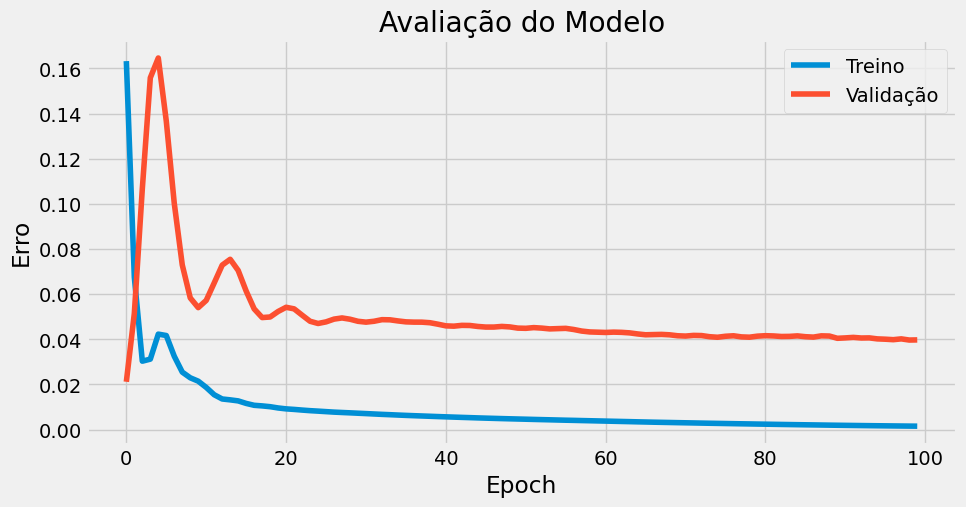

In [50]:
plt.plot(modelo_cnn_history.history['loss'])
plt.plot(modelo_cnn_history.history['val_loss'])
plt.title('Avaliação do Modelo')
plt.ylabel('Erro')
plt.xlabel('Epoch')
plt.legend(['Treino', 'Validação'], loc = 'upper right')
plt.show()

In [54]:
y_pred = modelo_cnn.predict(X_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step


In [55]:
y_pred


array([[0.18855633],
       [0.18864188],
       [0.2041991 ],
       [0.15320253],
       [0.10833924],
       [0.09115448],
       [0.11574699],
       [0.08938233],
       [0.11238907],
       [0.08969125],
       [0.1510479 ],
       [0.13499115],
       [0.10993803],
       [0.11134011],
       [0.15056849],
       [0.15750484],
       [0.09441411],
       [0.09887873],
       [0.1604745 ],
       [0.29903218],
       [0.2840709 ],
       [0.24837394]], dtype=float32)

In [56]:
y_train_inv = scaler_target.inverse_transform(y_train.reshape(1, -1))
y_test_inv = scaler_target.inverse_transform(y_test.reshape(1, -1))
y_pred_inv = scaler_target.inverse_transform(y_pred.reshape(1, -1))

In [57]:
y_train_inv = y_train_inv.flatten()
y_test_inv = y_test_inv.flatten()
y_pred_inv = y_pred_inv.flatten()

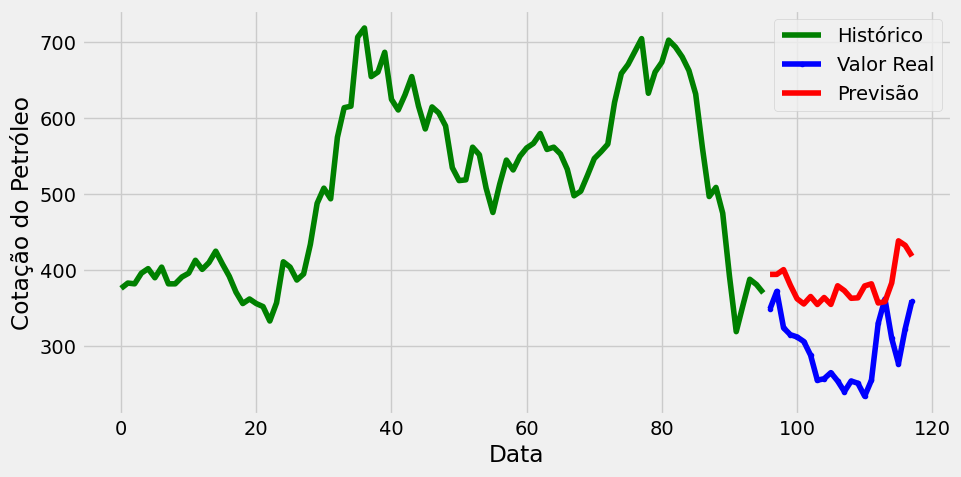

In [58]:
plt.plot(np.arange(0, len(y_train)),
         y_train_inv,
         color = 'green',
         label = 'Histórico')

plt.plot(np.arange(len(y_train),
                   len(y_train) + len(y_test)),
                y_test_inv,
                color = 'blue',
                marker = '.',
                label = 'Valor Real')

plt.plot(np.arange(len(y_train),
                   len(y_train) + len(y_test)),
                y_pred_inv,
                color = 'red',
                label = 'Previsão')

plt.ylabel('Cotação do Petróleo')
plt.xlabel('Data')
plt.legend()
plt.show()

In [59]:
def mda(actual: np.ndarray, predicted: np.ndarray):
    return np.mean((np.sign(actual[1:] - actual[:-1]) == np.sign(predicted[1:] - predicted[:-1])).astype(int))

In [60]:
MDA_mlp = mda(y_test_inv, y_pred_inv)
print('MDA:', MDA_mlp)

MAE_mlp = mean_absolute_error(y_test_inv, y_pred_inv)
print('MAE:', MAE_mlp)

MSE_mlp = mean_squared_error(y_test_inv, y_pred_inv)
print('MSE:', MSE_mlp)

RMSE_mlp = mean_squared_error(y_test_inv, y_pred_inv, squared = False)
print('RMSE:', RMSE_mlp)

EVS_mlp = explained_variance_score(y_test_inv, y_pred_inv)
print('EVS Score:', EVS_mlp)

MDA: 0.42857142857142855
MAE: 84.93964871493253
MSE: 8906.244066013913
RMSE: 94.37289900185282
EVS Score: 0.025938528488132384
